## EDA LAB

The General Social Survey (GSS) is a bi-annual nationally representative survey of Americans, with almost 7000 different questions asked since the survey began in the 1970s. It has straightforward questions about respondents' demographic information, but also questions like "Does your job regularly require you to perform repetitive or forceful hand movements or involve awkward postures?" or "How often do the demands of your job interfere with your family life?" There are a variety of controversial questions. No matter what you're curious about, there's something interesting in here to check out. The codebook is 904 pages (use CTRL+F to search it).

The data and codebook are available at:
https://gss.norc.org/us/en/gss/get-the-data.html

The datasets are so large that it might make sense to pick the variables you want, and then download just those variables from:
https://gssdataexplorer.norc.org/variables/vfilter

Here is your task:
1. Download a small (5-15) set of variables of interest.
2. Write a short description of the data you chose, and why. (1 page)
3. Load the data using Pandas. Clean them up for EDA. Do this in a notebook with comments or markdown chunks explaining your choices.
4. Produce some numeric summaries and visualizations. (1-3 pages)
5. Describe your findings in 1-2 pages.
6. If you have other content that you think absolutely must be included, you can include it in an appendix of any length.

For example, you might want to look at how aspects of a person's childhood family are correlated or not with their career or family choices as an adult. Or how political or religious affiliations correlate with drug use or sexual practices. It's an extremely wide-ranging survey.

Feel free to work with other people in groups, and ask questions!

2.

I chose the variables in my data because I saw that there was a filter tab for Asian Americans. I wanted to see if I could coorelate health towards specific stats about Asian Americans. This meant comparing the health conditions of Asian Americans that fit within ranges of "rich-poor", "hard working - lazy", "unintelligent - intelligent", and "self supporting - living off of welfare". I wanted to see how any of these values coorelate with each other. This is just because it was of interest to me as I am an Asian American that has thought about this topic in the past. As this data relates to people's opinions, I wanted to see if there was a coorelation on how people perceive Asian Americans on this scale.

In [9]:
# Clean the Data first

import pandas as pd
 
input_file = 'selected_gss_data.csv'
output_file = 'asian_health_cleaned.csv'
 
data = pd.read_csv(input_file)
 
# Drop rows with more than 1 missing value
cleaned_data = data[data.isnull().sum(axis=1) <= 1] # did this because there was a lot of empty data... Choosing to drop rows with more than 1 missing value, allowed for the data to be good enough
 
# Save the cleaned data to a new CSV file
cleaned_data.to_csv(output_file, index=False)

In [ ]:
# Cleaning of data for EDA and analysis 
 
# load the cleaned data
cleaned_data = pd.read_csv('asian_health_cleaned.csv')
 
# Drop the 'hlthinsr' column (wanted to just remove it right here because I realized all the data of it was empty)
if 'hlthinsr' in cleaned_data.columns:
    cleaned_data.drop(columns=['hlthinsr'], inplace=True)

# convert categorical columns to category dtype
categorical_columns = ['health']
for col in categorical_columns:
    cleaned_data[col] = cleaned_data[col].astype('category')

# numerical columns turn numeric (for analysis)
numeric_columns = cleaned_data.select_dtypes(include=['object']).columns
for col in numeric_columns:
    try:
        cleaned_data[col] = pd.to_numeric(cleaned_data[col], errors='coerce')
    except Exception as e:
        print(f"Could not convert column {col} to numeric: {e}")

# Fill missing values with mode in categorical columns
for col in categorical_columns:
    if cleaned_data[col].isnull().any():
        cleaned_data[col].fillna(cleaned_data[col].mode()[0], inplace=True)
 
# Save Data
cleaned_data.to_csv('asian_health_fully_cleaned.csv', index=False)

Summary statistics for numeric columns:
         year    wlthasns    workasns    intlasns    fareasns
count   762.0  762.000000  762.000000  762.000000  762.000000
mean   1990.0    4.275591    3.406824    4.450131    3.460630
std       0.0    1.184729    1.352413    1.221040    1.339444
min    1990.0    1.000000    1.000000    1.000000    1.000000
25%    1990.0    4.000000    2.000000    4.000000    2.000000
50%    1990.0    4.000000    3.000000    4.000000    4.000000
75%    1990.0    5.000000    4.000000    5.000000    4.000000
max    1990.0    7.000000    7.000000    7.000000    7.000000

Cross-tabulation of Health vs year:
year       1990
health         
excellent   1.0
fair        1.0
good        1.0
poor        1.0

Cross-tabulation of Health vs wlthasns:
wlthasns        1.0       2.0       3.0       4.0       5.0       6.0  \
health                                                                  
excellent  0.015625  0.042969  0.183594  0.363281  0.261719  0.113281   
fair     

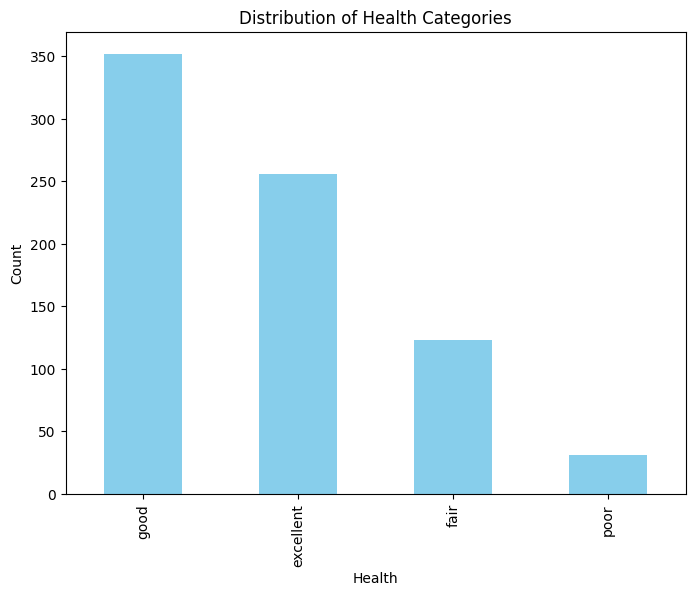

C:\Users\aaron\AppData\Local\Temp\ipykernel_8816\503945072.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='health', y='wlthasns', data=df, palette='Set2')


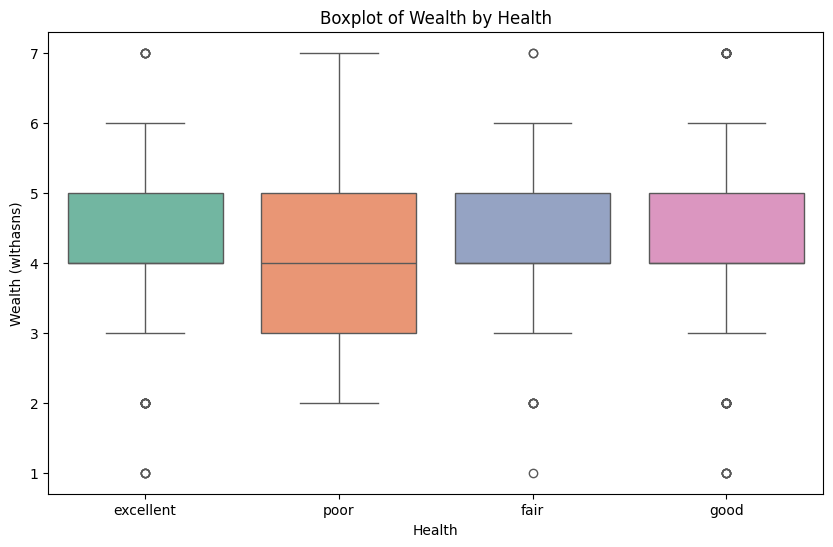

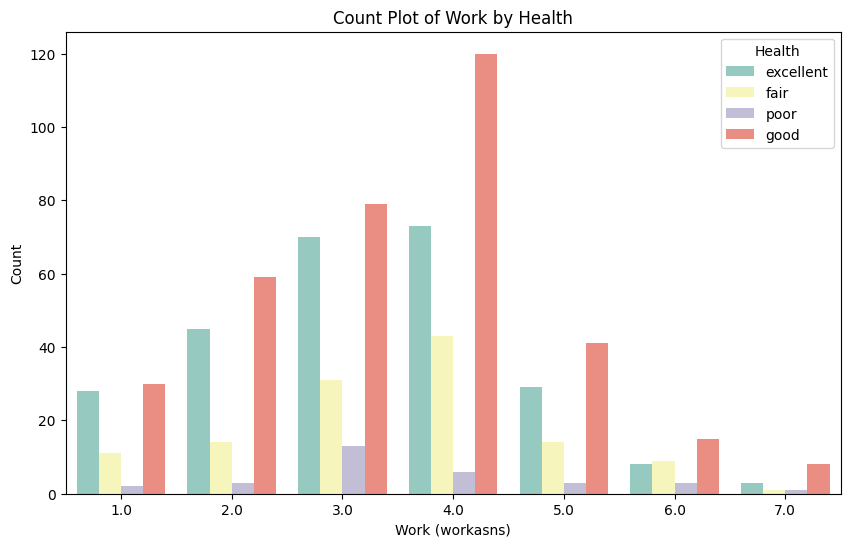

In [11]:
# 4 - Summaries and Visualizations 

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
 
df = pd.read_csv('asian_health_fully_cleaned.csv')
 
print("Summary statistics for numeric columns:")
print(df.describe())
 
# cross-tab each category with health
categories = [col for col in df.columns if col != 'health']
for category in categories:
    cross_tab = pd.crosstab(df['health'], df[category], normalize='index')
    print(f"\nCross-tabulation of Health vs {category}:")
    print(cross_tab)
 
# plot of health amount per category
plt.figure(figsize=(8, 6))
df['health'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribution of Health Categories')
plt.xlabel('Health')
plt.ylabel('Count')
plt.show()
 
# boxplots of wealth vs health
if 'wlthasns' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='health', y='wlthasns', data=df, palette='Set2')
    plt.title('Boxplot of Wealth by Health')
    plt.xlabel('Health')
    plt.ylabel('Wealth (wlthasns)')
    plt.show()
 
# plots of work level vs health
if 'workasns' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.countplot(x='workasns', hue='health', data=df, palette='Set3')
    plt.title('Count Plot of Work by Health')
    plt.xlabel('Work (workasns)')
    plt.ylabel('Count')
    plt.legend(title='Health')
    plt.show()

Findings:

Something that I found from my data analysis is that the GSS data only provides sufficient data on Asian Americans from 1990. This has skewing on how the data is interpreted, but this also means that we can look at how the health of the Asian Americans correlates within the specific year of 1990.

Something to conclude from this data is that there seems to be a positive coorelation between health and wealth perception. This meaning that people that think that Asian Americans are more wealthy tend to also believe that they are healthier compared to if they were less wealthy.

In relation to the work scale, it seems that there is more of a correlation towards hard-working Asian Americans being on the healther side by perception.

In relation to intelligence, this is also very similar. It is seen in the data that the more intelligent a person believes the Asian American is, the healthier they also think that the person would be.

In relation to the fairness scale in Asian American lives, it doesn't seem like there is too much of a real coorelation between this and their health.